In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
# from sklearn.metrics import confusion_matrix, classification_report
# from sklearn.metrics import roc_curve, auc
import helper

In [2]:
df = helper.prepare_data()

### Only PAY features

In [ ]:
X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].values
y = df['default.payment.next.month'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X,y = SMOTE(random_state=42).fit_resample(X,y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
class DecisionNode:
  def __init__(self, impurity=None, feature_index=None, threshold=None, left=None, right=None):
    self.left = left
    self.right = right
    # The largest impurity value of this node
    self.impurity = impurity
    # Index of the feature which make the best fit for this node.
    self.feature_index = feature_index
    # The threshold value for that feature to make the split.
    self.threshold = threshold

class LeafNode:
  def __init__(self, value):
    self.prediction_value = value

class DecisionTreeClassifierFromScratch:
  def __init__(self, min_sample_split=3, min_impurity=1e-7, max_depth=10, criterion='gini'):
    self.root = None
    self.min_sample_split = min_sample_split
    self.min_impurity = min_impurity
    self.max_depth = max_depth
    if criterion == 'entropy':
      self.criterion = 'entropy'
      self.criterion_name = 'entropy'
    else:
      self.criterion = 'gini'
      self.criterion_name = 'gini'
    self.n_classes_ = None
    self.classes_ = None

  def _impurity_from_counts(self, class_counts, n):
    """Compute impurity from class counts array (vectorized, no Python loop)."""
    if n == 0:
      return 0.0
    p = class_counts / n
    if self.criterion == 'gini':
      return 1.0 - np.sum(p * p)
    else:
      # entropy: avoid log2(0)
      mask = p > 0
      return -np.sum(p[mask] * np.log2(p[mask]))

  def _leaf_value_calculation(self, y):
    most_frequent_label = None
    max_count = 0
    unique_labels = np.unique(y)
    # iterate over all the unique values and find their frequentcy count.
    for label in unique_labels:
      count = len( y[y == label])
      if count > max_count:
        most_frequent_label = label
        max_count = count
    return most_frequent_label

  def _find_best_split_sorted(self, X, y):
    """
    Optimized best split finder using sorted feature values and cumulative
    class counts. For each feature:
      1. Sort samples by feature value — O(n log n)
      2. Scan from left to right, maintaining cumulative class counts for
         left and right partitions — O(n) per feature
      3. Only evaluate split at boundaries where the feature value changes
         (skip duplicate thresholds)
    Total per node: O(n_features * n * log(n))
    """
    n_samples = X.shape[0]
    n_features = X.shape[1]

    # Precompute total class counts for the node (vectorized)
    total_counts = np.zeros(self.n_classes_, dtype=np.float64)
    for c in range(self.n_classes_):
      total_counts[c] = np.sum(y == self.classes_[c])
    parent_impurity = self._impurity_from_counts(total_counts, n_samples)

    best_gain = 0.0
    best_feature = -1
    best_threshold = 0.0

    for feature_index in range(n_features):
      # Sort by this feature — O(n log n)
      sorted_indices = np.argsort(X[:, feature_index])
      sorted_feature_values = X[sorted_indices, feature_index]
      sorted_y = y[sorted_indices]

      # Cumulative class counts for the left partition
      left_counts = np.zeros(self.n_classes_, dtype=np.float64)
      right_counts = total_counts.copy()

      for i in range(1, n_samples):
        # Move sample i-1 from right to left partition
        c_idx = self.class_to_idx_[sorted_y[i - 1]]
        left_counts[c_idx] += 1.0
        right_counts[c_idx] -= 1.0

        # Skip if the feature value hasn't changed (no new split boundary)
        if sorted_feature_values[i] == sorted_feature_values[i - 1]:
          continue

        # Compute information gain using cumulative counts (O(n_classes))
        n_left = float(i)
        n_right = float(n_samples - i)
        left_impurity = self._impurity_from_counts(left_counts, n_left)
        right_impurity = self._impurity_from_counts(right_counts, n_right)

        gain = parent_impurity - (n_left / n_samples) * left_impurity - (n_right / n_samples) * right_impurity

        if gain > best_gain:
          best_gain = gain
          best_feature = feature_index
          # Threshold = midpoint between consecutive distinct values
          best_threshold = (sorted_feature_values[i - 1] + sorted_feature_values[i]) / 2.0

    return best_gain, best_feature, best_threshold

  def _build_tree(self, X, y, current_depth=0):
    n_samples = X.shape[0]
    # find the Information gain on each feature each values and return the question which splits the data very well
    if (n_samples >= self.min_sample_split) and (current_depth < self.max_depth):
      # find the best split/ which question split the data well.
      impurity, best_feature, best_threshold = self._find_best_split_sorted(X, y)
      if impurity > self.min_impurity and best_feature >= 0:
        # Partition using boolean mask — single split, no intermediate Xy array
        left_mask = X[:, best_feature] >= best_threshold
        right_mask = ~left_mask

        left_X = X[left_mask]
        left_y = y[left_mask]
        right_X = X[right_mask]
        right_y = y[right_mask]

        if len(left_y) > 0 and len(right_y) > 0:
          # Build subtrees for the right and left branch.
          true_branch = self._build_tree(left_X, left_y, current_depth + 1)
          false_branch = self._build_tree(right_X, right_y, current_depth + 1)
          return DecisionNode(impurity=impurity, feature_index=best_feature, threshold=best_threshold,
                              left=true_branch, right=false_branch)

    leaf_value = self._leaf_value_calculation(y)
    return LeafNode(value=leaf_value)

  def fit(self, X, y):
    # Precompute class information once for fast lookup during splits
    self.classes_ = np.unique(y)
    self.n_classes_ = len(self.classes_)
    self.class_to_idx_ = {c: i for i, c in enumerate(self.classes_)}
    self.root = self._build_tree(np.array(X, dtype=np.float64), np.array(y), current_depth=0)

  def predict_sample(self, x, tree=None):
    if isinstance(tree , LeafNode):
      return tree.prediction_value

    if tree is None:
      tree = self.root
    feature_value = x[tree.feature_index]
    branch = tree.right

    if isinstance(feature_value, int) or isinstance(feature_value, float):
      if feature_value >= tree.threshold:
        branch = tree.left
    elif feature_value == tree.threshold:
      branch = tree.left

    return self.predict_sample(x, branch)

  def predict(self, test_X):
    x = np.array(test_X)
    y_pred = [self.predict_sample(sample) for sample in x]
    y_pred = np.array(y_pred)
    return y_pred

  def predict_proba_sample(self, x, tree=None):
    if isinstance(tree , LeafNode):
      return tree.prediction_value

    if tree is None:
      tree = self.root
    feature_value = x[tree.feature_index]
    branch = tree.right

    if isinstance(feature_value, int) or isinstance(feature_value, float):
      if feature_value >= tree.threshold:
        branch = tree.left
    elif feature_value == tree.threshold:
      branch = tree.left

    return self.predict_proba_sample(x, branch)
  
  def predict_proba(self, test_X):
    x = np.array(test_X)
    y_pred_proba = [self.predict_proba_sample(sample) for sample in x]
    y_pred_proba = np.array(y_pred_proba)
    return y_pred_proba

  def draw_tree(self):
    self._draw_tree(self.root)

  def _draw_tree(self, tree = None, indentation = " ", depth=0):
    if isinstance(tree , LeafNode):
      print(indentation,"The predicted value -->", tree.prediction_value)
      return
    else:
      print(indentation,f"({depth}) Is {tree.feature_index}>={tree.threshold}?"
            f": {self.criterion_name}:{tree.impurity:.2f}")
      if tree.left is not None:
          print (indentation + '----- True branch :)')
          self._draw_tree(tree.left, indentation + "  ", depth+1)
      if tree.right is not None:
          print (indentation + '----- False branch :)')
          self._draw_tree(tree.right, indentation + "  ", depth+1)

Accuracy: 0.7237607310994184
Confusion Matrix:


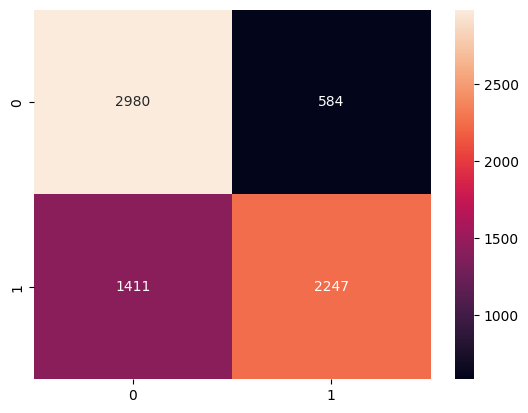

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.84      0.75      3564
           1       0.79      0.61      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



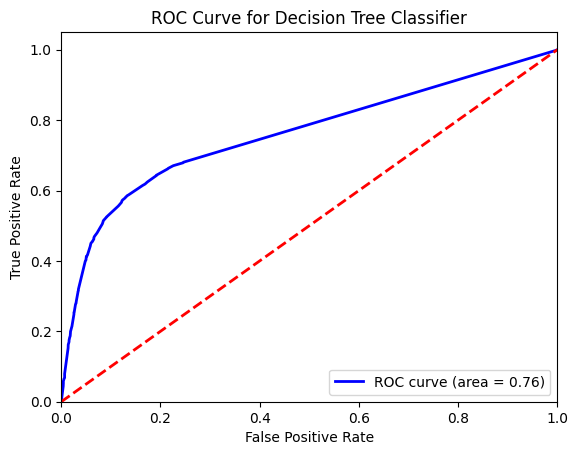

In [7]:
model = DecisionTreeClassifier(criterion='gini')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Decision Tree Classifier")

Accuracy: 0.7237607310994184
Confusion Matrix:


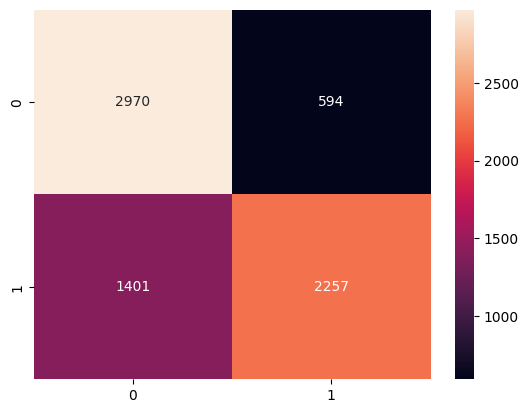

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.83      0.75      3564
           1       0.79      0.62      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



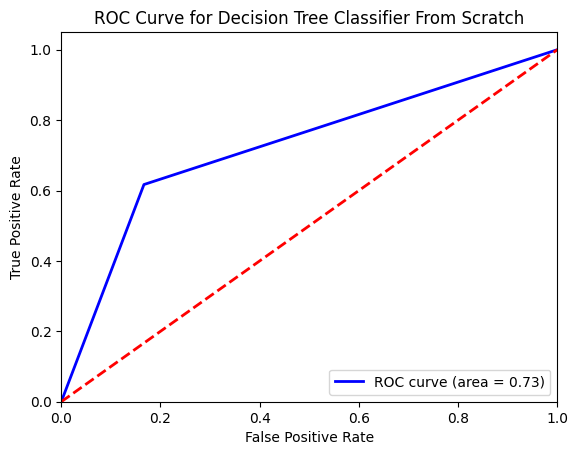

In [8]:
model_scratch = DecisionTreeClassifierFromScratch(criterion='gini')
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)
y_pred_proba_scratch = model_scratch.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred_scratch)
helper.plot_roc_curve(y_test, y_pred_proba_scratch, title="Decision Tree Classifier From Scratch")

Accuracy: 0.7240376626973137
Confusion Matrix:


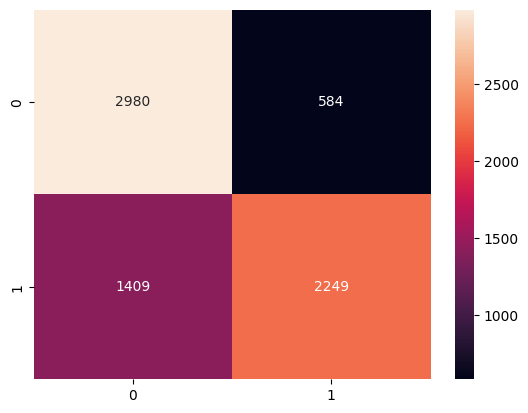

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.84      0.75      3564
           1       0.79      0.61      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



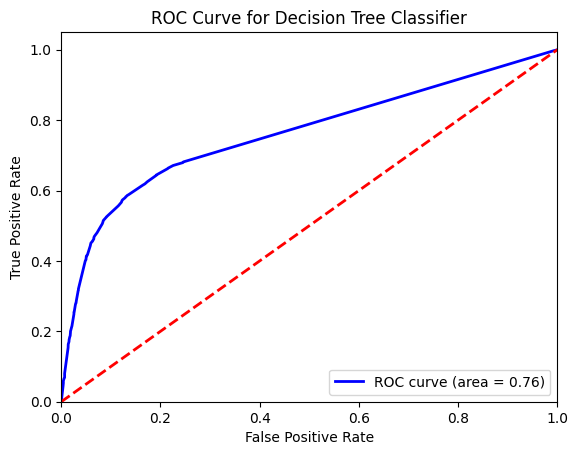

In [9]:
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Decision Tree Classifier")

Accuracy: 0.7238991968983661
Confusion Matrix:


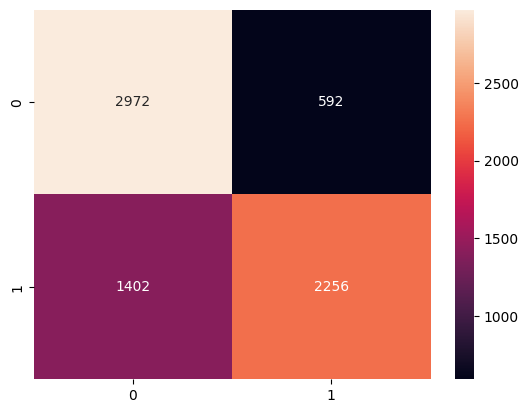

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.83      0.75      3564
           1       0.79      0.62      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.73      0.72      7222
weighted avg       0.74      0.72      0.72      7222



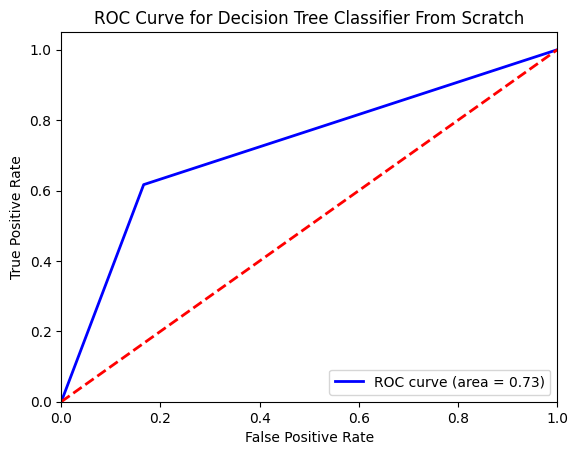

In [10]:
model_scratch = DecisionTreeClassifierFromScratch(criterion='entropy')
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)
y_pred_proba_scratch = model_scratch.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred_scratch)
helper.plot_roc_curve(y_test, y_pred_proba_scratch, title="Decision Tree Classifier From Scratch")

## All features

In [7]:
X = df.drop('default.payment.next.month', axis=1).values
y = df['default.payment.next.month'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X,y = SMOTE(random_state=42).fit_resample(X,y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Accuracy: 0.7664081971752977
Confusion Matrix:


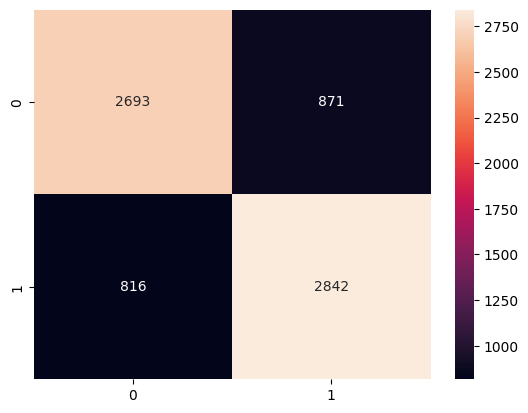

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      3564
           1       0.77      0.78      0.77      3658

    accuracy                           0.77      7222
   macro avg       0.77      0.77      0.77      7222
weighted avg       0.77      0.77      0.77      7222



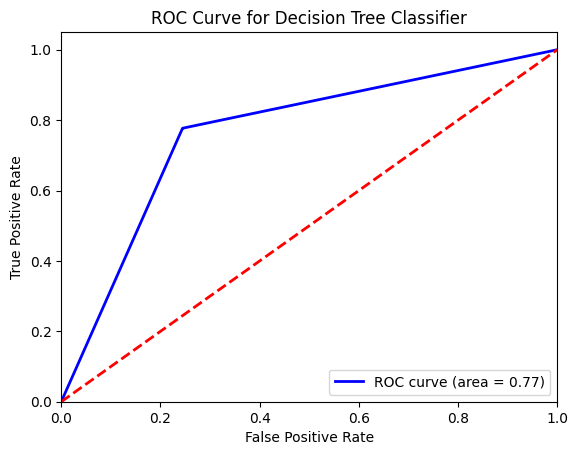

In [8]:
model = DecisionTreeClassifier(criterion='gini')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Decision Tree Classifier")

Accuracy: 0.7599003046247577
Confusion Matrix:


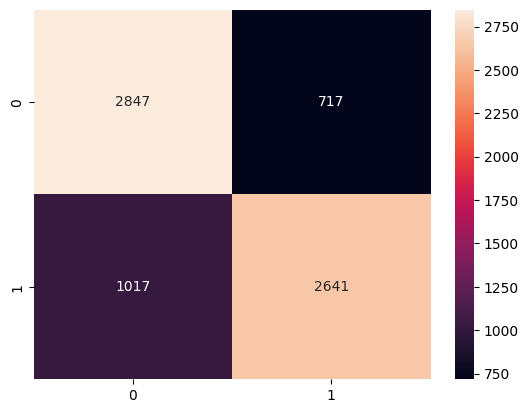

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77      3564
           1       0.79      0.72      0.75      3658

    accuracy                           0.76      7222
   macro avg       0.76      0.76      0.76      7222
weighted avg       0.76      0.76      0.76      7222



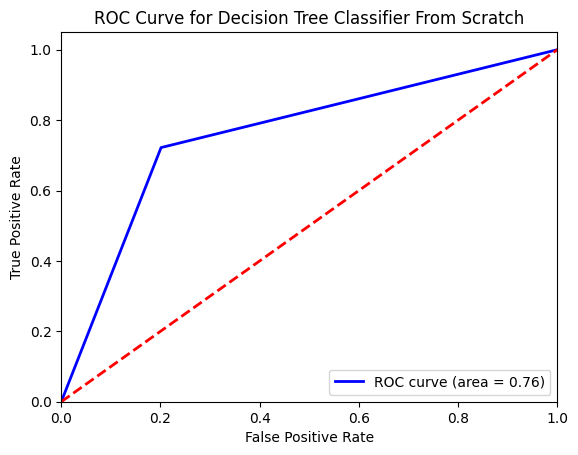

In [11]:
model_scratch = DecisionTreeClassifierFromScratch(criterion='gini')
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)
y_pred_proba_scratch = model_scratch.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred_scratch)
helper.plot_roc_curve(y_test, y_pred_proba_scratch, title="Decision Tree Classifier From Scratch")

Accuracy: 0.7715314317363611
Confusion Matrix:


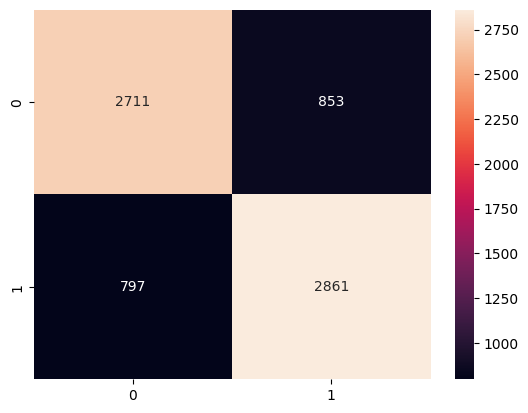

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.77      3564
           1       0.77      0.78      0.78      3658

    accuracy                           0.77      7222
   macro avg       0.77      0.77      0.77      7222
weighted avg       0.77      0.77      0.77      7222



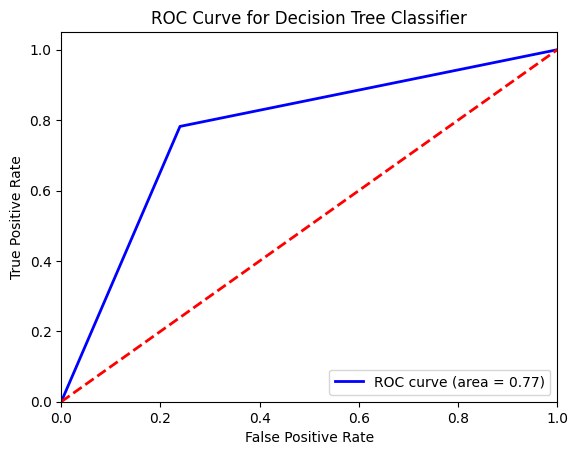

In [12]:
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Decision Tree Classifier")

Accuracy: 0.7561617280531708
Confusion Matrix:


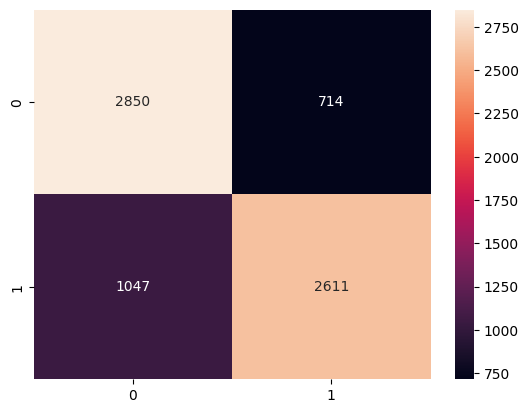

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76      3564
           1       0.79      0.71      0.75      3658

    accuracy                           0.76      7222
   macro avg       0.76      0.76      0.76      7222
weighted avg       0.76      0.76      0.76      7222



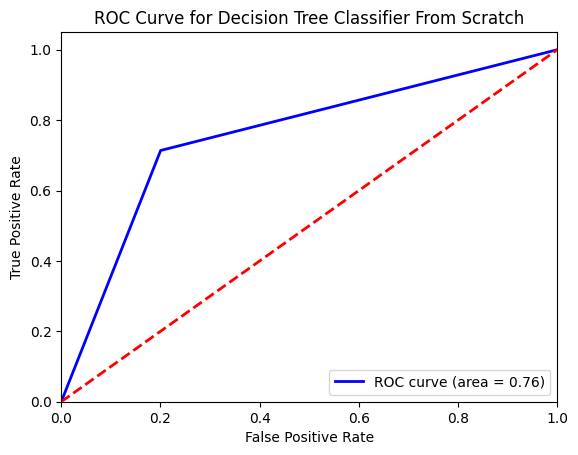

In [13]:
model_scratch = DecisionTreeClassifierFromScratch(criterion='entropy')
model_scratch.fit(X_train, y_train)
y_pred_scratch = model_scratch.predict(X_test)
y_pred_proba_scratch = model_scratch.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred_scratch)
helper.plot_roc_curve(y_test, y_pred_proba_scratch, title="Decision Tree Classifier From Scratch")

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 0.7817832764505119
Confusion Matrix:


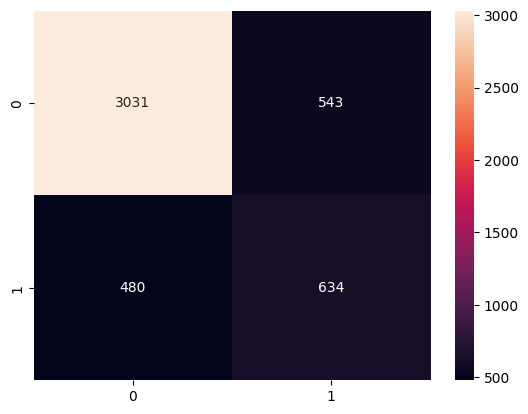

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      3574
           1       0.54      0.57      0.55      1114

    accuracy                           0.78      4688
   macro avg       0.70      0.71      0.70      4688
weighted avg       0.79      0.78      0.78      4688



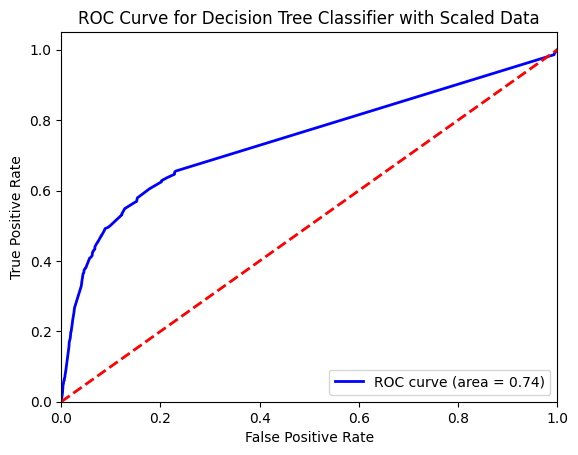

In [8]:
model = DecisionTreeClassifier(criterion='gini')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Decision Tree Classifier with Scaled Data")

Accuracy: 0.7824232081911263
Confusion Matrix:


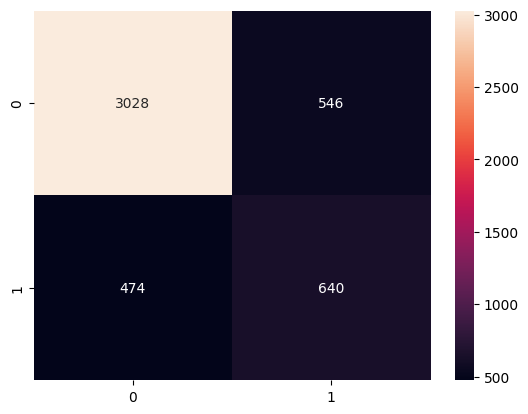

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      3574
           1       0.54      0.57      0.56      1114

    accuracy                           0.78      4688
   macro avg       0.70      0.71      0.71      4688
weighted avg       0.79      0.78      0.78      4688



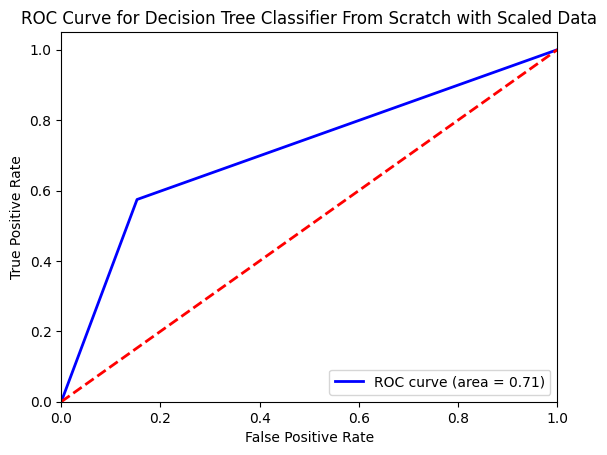

In [9]:
model_scratch = DecisionTreeClassifierFromScratch(criterion='gini')
model_scratch.fit(X_train_scaled, y_train)
y_pred = model_scratch.predict(X_test_scaled)
y_pred_proba = model_scratch.predict_proba(X_test_scaled)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Decision Tree Classifier From Scratch with Scaled Data")